# **"Internship task by Arch Technology"**

**Month : 1**

**Task : 2**

**Project Name : Sctock Price Prediction**

**Data Source : From Kaggle**

**Domain : Data Science**

**Submitted Date : 27-Apl-2026**

**Submitted By : Palwasha Mushtaq**

# **"Data Introduction"**
**"Stock market prediction is an important area in financial analysis that helps investors make better decisions by understanding price trends. In this project, historical stock data along with sentiment-related features is used to build a prediction model for stock closing prices."**

**"The dataset includes key features such as Open, High, Low, Close, and Volume, along with sentiment-based variables. After data preprocessing, a Linear Regression model is applied to predict the closing price based on selected numerical features."**

**"The main goal of this project is to analyze stock market behavior and develop a simple and effective model that can predict price trends with reasonable accuracy."**

# **"Import Libraries"**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn .linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error

# **"Load Dataset"**

In [60]:
df = pd.read_csv('stock_price_dataset_csv')
print(df.head())

   Adj Close      Close       High        Low       Open     Volume Company  \
0   8.532785  10.115357  10.135000   9.851786   9.860000  658677600   Apple   
1   8.712500   8.712500   8.897000   8.686500   8.816500   84050000  Amazon   
2   8.778500   8.778500   8.950000   8.679500   8.686000  116210000  Amazon   
3   8.887500   8.887500   8.987500   8.728000   8.843000   93130000  Amazon   
4  11.446334  13.569286  13.602857  13.282143  13.321429  467832400   Apple   

         Date  Target  Score  Comments  \
0   9/20/2010       1      0         0   
1  12/13/2010       1      7         5   
2  12/15/2010       1      8         0   
3   2/24/2011       1      5         1   
4   9/12/2011      -1      5        16   

                                        Cleaned_Text Sentiment  \
0                 stock market game iphone ipad play  Positive   
1                  hussman warning awful time invest   Neutral   
2      awful time invest reflection lost opportunity  Negative   
3       

# **"Data Overview (Data Understanding)"**

In [61]:
print('DATA COLUMNS')
print(df.columns)
print('=========================================================================================================================')
print('DATA SHAPE')
print(df.shape)
print('=========================================================================================================================')
print('DATA INFORMATION')
print(df.info())
print('=========================================================================================================================')
print('"DESCRIPTIVE STATISTIC SUMMERY')
print(df.describe())
print('=========================================================================================================================')
print('UNIQUES VALUES OF THE DATA')
print(df.nunique())

DATA COLUMNS
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company',
       'Date', 'Target', 'Score', 'Comments', 'Cleaned_Text', 'Sentiment',
       'Sentiment_Score'],
      dtype='object')
DATA SHAPE
(12069, 14)
DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12069 entries, 0 to 12068
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Adj Close        12069 non-null  float64
 1   Close            12069 non-null  float64
 2   High             12069 non-null  float64
 3   Low              12069 non-null  float64
 4   Open             12069 non-null  float64
 5   Volume           12069 non-null  int64  
 6   Company          12069 non-null  object 
 7   Date             12069 non-null  object 
 8   Target           12069 non-null  int64  
 9   Score            12069 non-null  int64  
 10  Comments         12069 non-null  int64  
 11  Cleaned_Text     11915 non-null  objec

**Afer overviwed the data, it is analyzed that, "The dataset contains 12,069 observations and 14 features, including both numerical and categorical variables. Key numerical features include stock price indicators such as Open, High, Low, Close, and Volume, while categorical features include Company and Sentiment. The dataset also includes additional sentiment-related variables such as Sentiment Score and textual data".**

**"The descriptive statistics indicate significant variation in stock prices and trading volume, reflecting the dynamic nature of the stock market. Additionally, the dataset includes a mix of unique values across features, with some categorical columns having limited distinct values."**

# **"Data Preprocessing"**

**"Data Cleaning"**

**"Check Misssing Values"**

In [62]:
df.isnull().sum()

Adj Close            0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Company              0
Date                 0
Target               0
Score                0
Comments             0
Cleaned_Text       154
Sentiment            0
Sentiment_Score      0
dtype: int64

**"The dataset was checked for missing values, and it was observed that all columns contain complete data except for the 'Cleaned_Text' column, which has 154 missing values."**

**"Check Duplicate Values"**

In [63]:
df.duplicated().sum()

np.int64(0)

**"The dataset was checked for duplicate values, and no duplicates were found."**

**"Drop Unnecessary Columns (Company,Cleaned_Text,Sentiment,Sentiment_Score,Comments,Date,Target,Score)"**

In [51]:
df.drop(columns=["Company","Cleaned_Text","Sentiment","Sentiment_Score","Comments","Date","Target","Score"],inplace= True)
print(df)

        Adj Close       Close        High         Low        Open     Volume
0        8.532785   10.115357   10.135000    9.851786    9.860000  658677600
1        8.712500    8.712500    8.897000    8.686500    8.816500   84050000
2        8.778500    8.778500    8.950000    8.679500    8.686000  116210000
3        8.887500    8.887500    8.987500    8.728000    8.843000   93130000
4       11.446334   13.569286   13.602857   13.282143   13.321429  467832400
...           ...         ...         ...         ...         ...        ...
12064  205.740005  205.740005  207.639999  205.050003  206.979996   28061600
12065  205.740005  205.740005  207.639999  205.050003  206.979996   28061600
12066  207.889999  207.889999  208.199997  204.589996  205.830002   24892400
12067  237.330002  237.330002  237.809998  233.970001  234.809998   28481400
12068  237.330002  237.330002  237.809998  233.970001  234.809998   28481400

[12069 rows x 6 columns]


**"During data preprocessing, irrelevant columns such as Company, Cleaned_Text, Sentiment, Sentiment_Score, Comments, Date, Target, and Score were removed to focus on key numerical features. Additionally, the dataset was checked for duplicate values, and appropriate actions were taken to ensure data quality."**

# **"Exploratory Data Analysis (EDA)"**

# **"Data Visulization"**

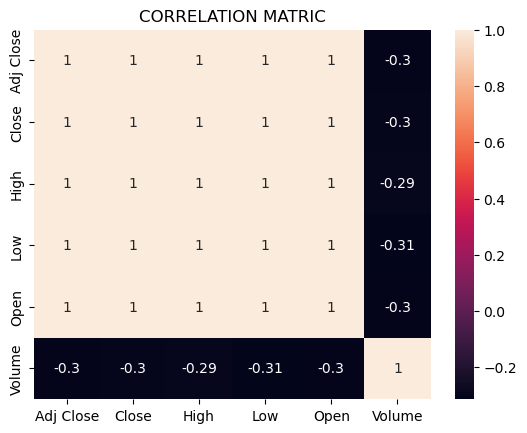

In [52]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot = True)
plt.title('CORRELATION MATRIC')
plt.show()

**"The heatmap shows the relationship between different features. Strong correlation is observed between Open, High, Low, and Close prices."**

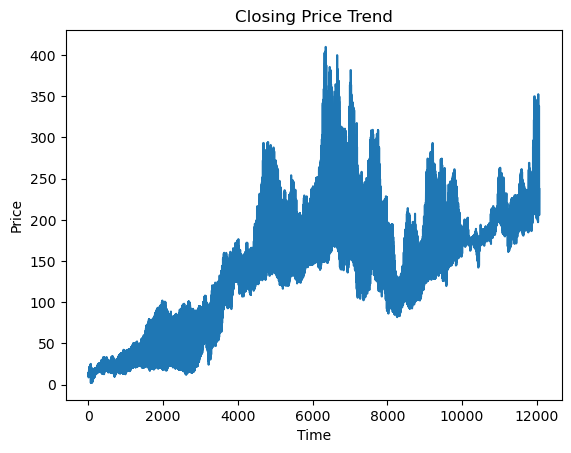

In [53]:
plt.plot(df['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

**""The closing price shows fluctuations over time, reflecting market volatility."**

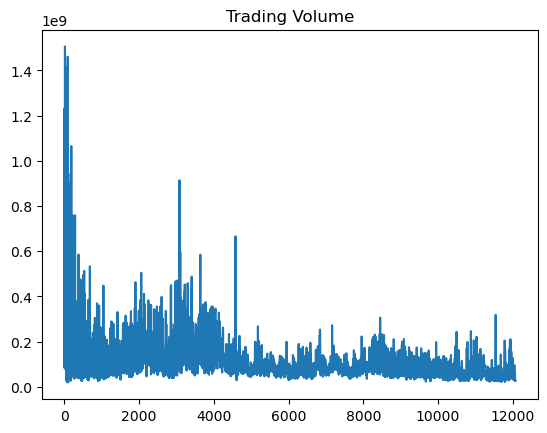

In [54]:
plt.plot(df['Volume'])
plt.title("Trading Volume")
plt.show()

**"The above graph shows, Trading Volume over time X-axis shows sequential trading sessions (0-12000), 
Y-axis shows volume in billions. Initial period shows extremely high trading activity 
with volume >1.4B, followed by declining trend with intermittent spikes."**

**"The graph shows trading activity over time."**

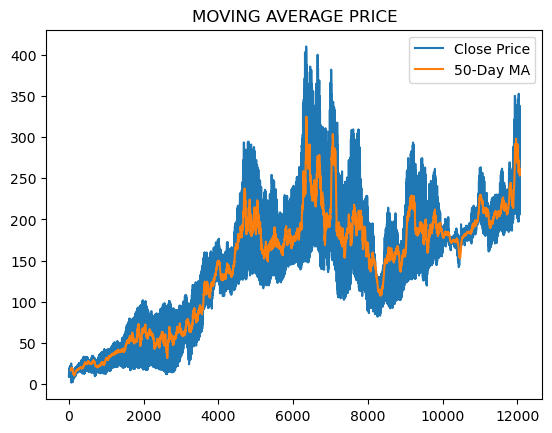

In [55]:
df['MA50'] = df['Close'].rolling(window=50).mean()
plt.title("MOVING AVERAGE PRICE")
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50-Day MA')
plt.legend()
plt.show()

**"The moving average helps in identifying the overall trend by smoothing price fluctuations."**

**"A 50-day moving average was applied to smooth the fluctuations in stock prices and to better visualize the overall trend."**

# **"Feature Selection"**

In [56]:
X = df[['Open','High','Low','Volume']]
y = df['Close']

**"Relevant numerical features including Open, High, Low, and Volume were used as independent variables, while the Close price was selected as the dependent variable for prediction."**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, shuffle=False)
print('TRAINING DATA')
print(X_train)
print('TEST DATA')
print(X_test)

TRAINING DATA
            Open        High         Low     Volume
0       9.860000   10.135000    9.851786  658677600
1       8.816500    8.897000    8.686500   84050000
2       8.686000    8.950000    8.679500  116210000
3       8.843000    8.987500    8.728000   93130000
4      13.321429   13.602857   13.282143  467832400
...          ...         ...         ...        ...
9650  189.570007  190.960007  188.649994   54412900
9651  140.910004  143.320007  139.520004   49653500
9652  140.910004  143.320007  139.520004   49653500
9653  140.910004  143.320007  139.520004   49653500
9654  140.910004  143.320007  139.520004   49653500

[9655 rows x 4 columns]
TEST DATA
             Open        High         Low     Volume
9655   140.910004  143.320007  139.520004   49653500
9656   142.660004  145.229996  142.539993   49636700
9657   142.660004  145.229996  142.539993   49636700
9658   232.000000  237.389999  226.539993  142532800
9659   232.000000  237.389999  226.539993  142532800
...      

**"Training data (80%) was used to train the model on historical stock price patternsand Testing data (20%) was used to check how well the model performs on new, unseen data."**

# **"Model Building"**  

# **"Linear Regression"**

In [58]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**“A Linear Regression model was initialized and trained using the training data (X_train and y_train) to learn the relationship between input features and the target variable.”**

In [37]:
y_pred = model.predict(X_test)
print(y_pred)

[141.86705571 144.82358563 144.82358563 ... 206.83054291 236.69689479
 236.69689479]


**“The model outputs a continuous range of predicted stock prices, indicating the estimated future values based on learned relationships from historical data.”**

**Evaluation"**

In [38]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MEAN_ABSOLUTE_ERROR:", mae)
print("MEAN_SEQUARED_ERROR:", mse)

MEAN_ABSOLUTE_ERROR: 1.176609776004132
MEAN_SEQUARED_ERROR: 2.8544591874014316


**“The model was evaluated using MAE and MSE metrics. The Mean Absolute Error was 1.1766, which shows the average absolute deviation between predicted and actual stock prices. The Mean Squared Error was 2.8544, indicating that the model maintains a low level of overall prediction error and performs reasonably well on the dataset.”**

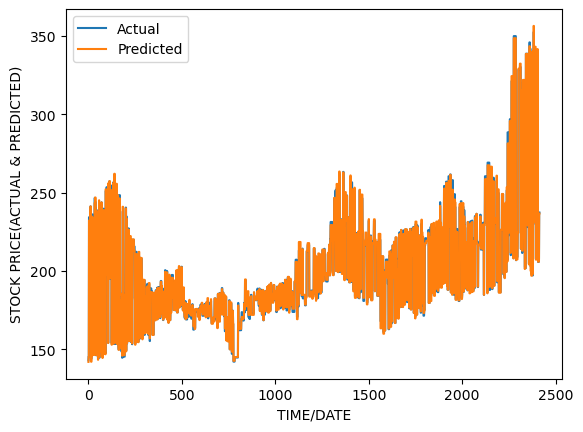

In [67]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.xlabel('TIME/DATE')
plt.ylabel('STOCK PRICE(ACTUAL & PREDICTED)')
plt.show()

**"The model shows high accuracy with predicted values (orange) overlapping actual values (blue)."**

**"Trend and volatility are well captured with minimal deviation.confirming good model performance on test data."**

# **Conclusion"**

**"The stock price prediction model was developed using a dataset containing 12,069 observations and 14 features, including stock market indicators such as Open, High, Low, Close, and Volume along with sentiment-based variables. After data preprocessing, irrelevant and text-based columns were removed to focus on numerical features for model training."**

**"A Linear Regression model was trained on the dataset using Open, High, Low, and Volume as input features to predict the Close price. The dataset was split into training and testing sets to evaluate model performance."**

**"The model performed well on the test data, achieving a Mean Absolute Error (MAE) of 1.17 and a Mean Squared Error (MSE) of 2.85, which indicates a low level of prediction error. The comparison between actual and predicted values shows that the model closely follows the real stock price trend with minimal deviation."**

**"Additionally, visualization results confirm that the model successfully captures market trends and volatility. The predicted values closely overlap with actual values, indicating strong predictive performance and reliability for short-term stock price estimation."**


# **"Recommendations"**

**"More advanced machine learning models such as Random Forest, XGBoost, or LSTM (deep learning) can be applied to further improve prediction accuracy."**


**"Incorporating technical indicators (e.g., Moving Averages, RSI, MACD) may enhance model performance."**


**"Sentiment analysis features should be properly integrated, as market sentiment can significantly influence stock prices."**


**"More feature engineering (lag features, rolling averages) can help capture time-series dependencies better."**


**"Hyperparameter tuning and cross-validation should be applied to ensure better generalization of the model."**


**"Future work can focus on time-series forecasting models instead of simple regression for improved long-term predictions."**